# Campus Point Wave Model Validation
**Question:** How well does CDIP's operational wave model (MOP B0385) predict wave conditions at Campus Point, and where does it fail?

**Data sources:**
- MOP B0385: CDIP's operational nearshore wave model at Campus Point (10m depth)
- SPOT-1644: Nick Nidzieko's Sofar buoy at Campus Point (Jan–Apr 2026)
- Harvest (CDIP 071): Offshore swell buoy, used to diagnose model errors

**Motivation:** O'Reilly et al. (2016) showed the Santa Barbara Channel 
is one of the hardest regions to model on the California coast due to 
wave shadowing by the Channel Islands. This notebook independently 
validates that finding at Campus Point using a consumer-grade buoy.

## Step 1: Load the CDIP Wave Model (MOP B0385)

MOP (Monthly Observation Points) is CDIP's operational wave model, built on O'Reilly et al. (2016). It predicts wave height, period, and direction at fixed nearshore points along the California coast. B0385 is the transect closest to Campus Point Beach, at 10m water depth. The dataset contains hourly predictions going back to January 2000.

In [4]:
import xarray as xr

url = "https://thredds.cdip.ucsd.edu/thredds/dodsC/cdip/model/MOP_alongshore/B0385_hindcast.nc"

ds_mop = xr.open_dataset(url)
print(ds_mop)

<xarray.Dataset> Size: 139MB
Dimensions:                     (waveTime: 221328, metaBoundsCount: 2,
                                 waveFrequency: 20)
Coordinates:
  * waveTime                    (waveTime) datetime64[ns] 2MB 2000-01-01 ... ...
  * waveFrequency               (waveFrequency) float32 80B 0.04 0.045 ... 0.4
    metaLatitude                float32 4B ...
    metaLongitude               float32 4B ...
Dimensions without coordinates: metaBoundsCount
Data variables: (12/26)
    waveTimeBounds              (waveTime, metaBoundsCount) datetime64[ns] 4MB ...
    waveFlagPrimary             (waveTime) float32 885kB ...
    waveFlagSecondary           (waveTime) float32 885kB ...
    waveHs                      (waveTime) float32 885kB ...
    waveTp                      (waveTime) float32 885kB ...
    waveTa                      (waveTime) float32 885kB ...
    ...                          ...
    waveMeanDirection           (waveTime, waveFrequency) float32 18MB ...
    waveA

## Step 2: Load Nick's Buoy (SPOT-1644) and Align with Model

SPOT-1644 is a Sofar Ocean buoy deployed by Nick Nidzieko's lab directly at Campus Point. It measures actual wave conditions every 30 minutes in the water.

We load three months of buoy data (January–April 2026), resample it to hourly to match the model's time resolution, and align the two datasets by timestamp. This gives us 2,106 matched hour-by-hour comparisons between what the model predicted and what the buoy actually measured.

The aligned dataset has two key columns:
- Hs_spot: wave height measured by the buoy (ground truth)
- Hs_mop: wave height predicted by the CDIP model

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import xarray as xr
from scipy import stats

# --- Load and clean Nick's buoy CSVs ---
def load_sofar(filepath):
    df = pd.read_csv(filepath)
    
    # Convert epoch to datetime
    df['time'] = pd.to_datetime(df['Epoch Time'], unit='s', utc=True)
    
    # Drop rows missing wave data (diagnostic-only rows)
    df = df[df['Significant Wave Height (m)'] != '-'].copy()
    
    # Convert columns to numeric
    for col in ['Significant Wave Height (m)', 'Peak Period (s)', 
                'Peak Direction (deg)', 'Mean Direction (deg)']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    df = df.dropna(subset=['Significant Wave Height (m)'])
    df = df.set_index('time').sort_index()
    return df[['Significant Wave Height (m)', 'Peak Period (s)',
               'Peak Direction (deg)', 'Mean Direction (deg)']]

print("Loading Sofar CSVs...")
dfs = []
for f in [
    'data/SPOT-1644_2026-01-06_2026-02-06_download.csv',
    'data/SPOT-1644_2026-02-06_2026-03-06_download.csv',
    'data/SPOT-1644_2026-03-06_2026-04-06_download.csv'
]:
    dfs.append(load_sofar(f))

spot = pd.concat(dfs).sort_index()
spot = spot[~spot.index.duplicated()]  # drop any overlap between files
print(f"SPOT-1644: {len(spot)} observations from {spot.index[0]} to {spot.index[-1]}")

# --- Load MOP B0385 hindcast ---
print("\nLoading MOP B0385...")
ds_mop = xr.open_dataset(
    "https://thredds.cdip.ucsd.edu/thredds/dodsC/cdip/model/MOP_alongshore/B0385_nowcast.nc"
)

# Trim MOP to same time range as SPOT
t_start = spot.index[0].to_datetime64()
t_end   = spot.index[-1].to_datetime64()
mop_times = ds_mop['waveTime'].values
mask = (mop_times >= t_start) & (mop_times <= t_end)

mop = pd.DataFrame({
    'Hs':  ds_mop['waveHs'].values[mask],
    'Tp':  ds_mop['waveTp'].values[mask],
    'Dp':  ds_mop['waveDp'].values[mask],
    'flag': ds_mop['waveFlagPrimary'].values[mask]
}, index=pd.DatetimeIndex(mop_times[mask], tz='UTC'))

# Quality filter
mop = mop[mop['flag'] == 1.0]
print(f"MOP B0385: {len(mop)} hourly records in range")

# --- Align to hourly ---
# Resample SPOT to hourly means to match MOP's hourly output
spot_hourly = spot.resample('1h').mean()

# Inner join on time
aligned = spot_hourly.join(mop[['Hs', 'Tp', 'Dp']], how='inner')
aligned.columns = ['Hs_spot', 'Tp_spot', 'Dp_spot', 'Dir_spot',
                   'Hs_mop', 'Tp_mop', 'Dp_mop']
aligned = aligned.dropna()
print(f"\nAligned pairs: {len(aligned)}")
print(aligned.head())

Loading Sofar CSVs...
SPOT-1644: 4162 observations from 2026-01-06 07:38:31+00:00 to 2026-04-05 04:45:31+00:00

Loading MOP B0385...
MOP B0385: 2133 hourly records in range

Aligned pairs: 2106
                           Hs_spot  Tp_spot   Dp_spot  Dir_spot    Hs_mop  \
time                                                                        
2026-01-06 08:00:00+00:00    0.670     9.30  226.1210  186.4065  0.335218   
2026-01-06 09:00:00+00:00    0.665     7.91  242.7340  185.7090  0.360891   
2026-01-06 10:00:00+00:00    0.660     8.91  232.8515  182.8120  0.381822   
2026-01-06 11:00:00+00:00    0.680     5.86  179.0540  182.4660  0.387841   
2026-01-06 12:00:00+00:00    0.635     8.19  242.0615  211.7065  0.388103   

                              Tp_mop      Dp_mop  
time                                              
2026-01-06 08:00:00+00:00  11.111111  198.748962  
2026-01-06 09:00:00+00:00  11.111111  197.647293  
2026-01-06 10:00:00+00:00  11.111111  198.697372  
2026-01-06 

## Model Validation: MOP vs SPOT-1644
We compare hourly Hs predictions from MOP against SPOT-1644 observations 
over 3 months. Skill is measured using R², bias, and RMSE following 
O'Reilly et al. (2016) Equation 7.


--- MOP B0385 vs SPOT-1644 — Hs ---
N        = 2106
Mean obs = 0.655m,  Mean pred = 0.527m
R²       = 0.531
Bias     = -0.128m  (-19.5%)
RMSE     = 0.129m  (19.7%)

--- Winter (Oct-Mar) ---
N        = 2005
Mean obs = 0.655m,  Mean pred = 0.527m
R²       = 0.533
Bias     = -0.128m  (-19.6%)
RMSE     = 0.130m  (19.8%)

--- Summer (Apr-Sep) ---
N        = 101
Mean obs = 0.646m,  Mean pred = 0.532m
R²       = 0.495
Bias     = -0.115m  (-17.7%)
RMSE     = 0.107m  (16.6%)


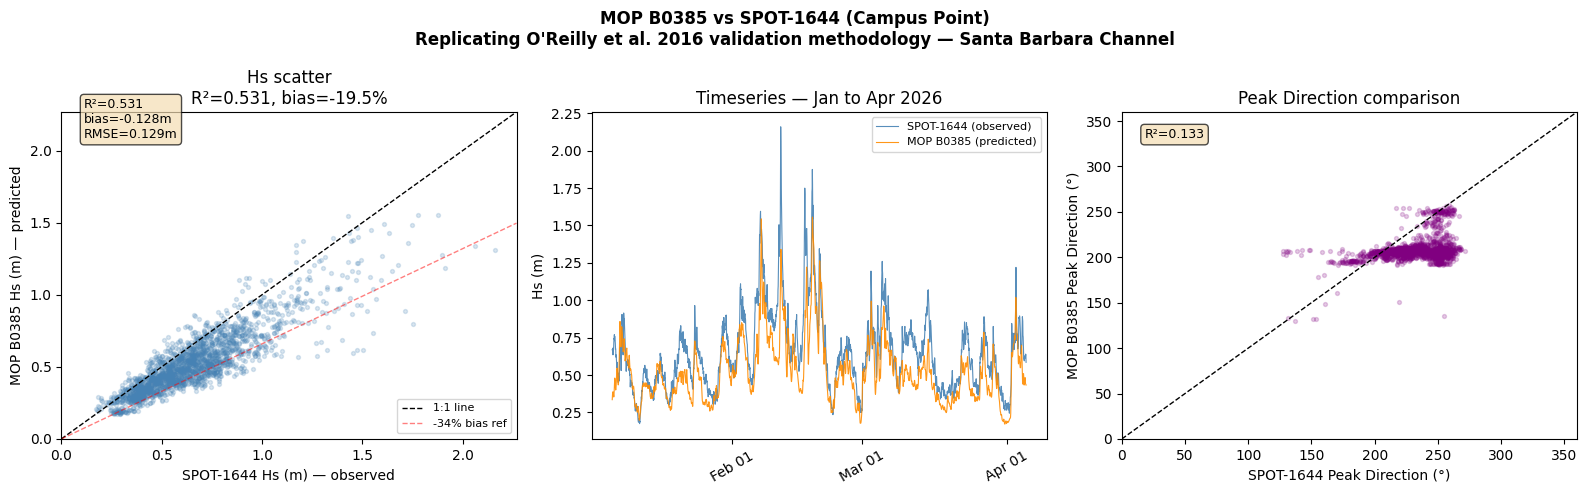

Done


In [9]:
# --- Skill metrics (paper Eq 7) ---
def skill_metrics(obs, pred, label=''):
    bias = np.mean(pred - obs)
    rmse = np.sqrt(np.mean((pred - obs - bias)**2))
    ss   = 1 - np.sum((pred - obs)**2) / np.sum((obs - np.mean(obs))**2)
    pct_bias = 100 * bias / np.mean(obs)
    pct_rmse = 100 * rmse / np.mean(obs)
    print(f"\n--- {label} ---")
    print(f"N        = {len(obs)}")
    print(f"Mean obs = {np.mean(obs):.3f}m,  Mean pred = {np.mean(pred):.3f}m")
    print(f"R²       = {ss:.3f}")
    print(f"Bias     = {bias:.3f}m  ({pct_bias:.1f}%)")
    print(f"RMSE     = {rmse:.3f}m  ({pct_rmse:.1f}%)")
    return ss, bias, rmse

obs  = aligned['Hs_spot'].values
pred = aligned['Hs_mop'].values

R2, bias, rmse = skill_metrics(obs, pred, 'MOP B0385 vs SPOT-1644 — Hs')

# --- Seasonal split ---
months  = aligned.index.month
winter  = (months >= 10) | (months <= 3)
summer  = ~winter

if winter.sum() > 10:
    skill_metrics(obs[winter], pred[winter], 'Winter (Oct-Mar)')
if summer.sum() > 10:
    skill_metrics(obs[summer], pred[summer], 'Summer (Apr-Sep)')

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('MOP B0385 vs SPOT-1644 (Campus Point)\n'
             'Replicating O\'Reilly et al. 2016 validation methodology — Santa Barbara Channel',
             fontsize=12, fontweight='bold')

# 1. Scatter
ax = axes[0]
ax.scatter(obs, pred, alpha=0.2, s=8, color='steelblue')
lim = max(obs.max(), pred.max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', lw=1, label='1:1 line')
ax.plot([0, lim], [0, lim*0.66], 'r--', lw=1, alpha=0.5, label='-34% bias ref')
ax.set_xlabel('SPOT-1644 Hs (m) — observed')
ax.set_ylabel('MOP B0385 Hs (m) — predicted')
ax.set_title(f'Hs scatter\nR²={R2:.3f}, bias={bias*100/np.mean(obs):.1f}%')
ax.legend(fontsize=8)
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.text(0.05, 0.92, f'R²={R2:.3f}\nbias={bias:.3f}m\nRMSE={rmse:.3f}m',
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

# 2. Timeseries
ax = axes[1]
ax.plot(aligned.index, obs,  color='steelblue', lw=0.8,
        alpha=0.9, label='SPOT-1644 (observed)')
ax.plot(aligned.index, pred, color='darkorange', lw=0.8,
        alpha=0.9, label='MOP B0385 (predicted)')
ax.set_ylabel('Hs (m)')
ax.set_title('Timeseries — Jan to Apr 2026')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

# 3. Direction comparison
ax = axes[2]
ax.scatter(aligned['Dp_spot'], aligned['Dp_mop'],
           alpha=0.2, s=8, color='purple')
ax.plot([0, 360], [0, 360], 'k--', lw=1)
ax.set_xlabel('SPOT-1644 Peak Direction (°)')
ax.set_ylabel('MOP B0385 Peak Direction (°)')
ax.set_title('Peak Direction comparison')
ax.set_xlim(0, 360); ax.set_ylim(0, 360)
R2_dir = stats.pearsonr(aligned['Dp_spot'], aligned['Dp_mop'])[0]**2
ax.text(0.05, 0.92, f'R²={R2_dir:.3f}',
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.savefig('mop_vs_spot_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done")

### The ~20% bias number

The -19.5% bias is calculated directly from the 2,106 matched pairs: we take the average of (model prediction − buoy observation) for every hour, divide by the average observed wave height, and express it as a percentage.

Concretely: the buoy averaged 0.655m over this period; the model averaged 0.527m. That gap — 0.128m — is 19.5% of 0.655m. So on average, if CDIP says 1.0m, the buoy is actually seeing about 1.2m.

In the scatter plot, a perfect model would put every dot on the black dashed 1:1 line. Instead almost every dot sits below it — the model is consistently low. The timeseries shows the same thing: the orange line (model) tracks the blue line (buoy) in timing but is almost always lower, with the biggest gaps during the large swell events in early March — exactly the conditions surfers care most about.

R² = 0.531 means the model explains about 53% of the variability in wave height. A perfect model would be 1.0; a model that just predicts the mean every time would be 0.0. So the model knows roughly when waves are bigger or smaller, but can't nail the magnitude.

## Why does the model fail?
O'Reilly et al. hypothesize that Santa Barbara Channel errors are caused 
by wave diffraction through Channel Islands gaps — physics the linear 
refraction model cannot capture. We test this by splitting model skill 
by offshore swell direction at Harvest buoy.

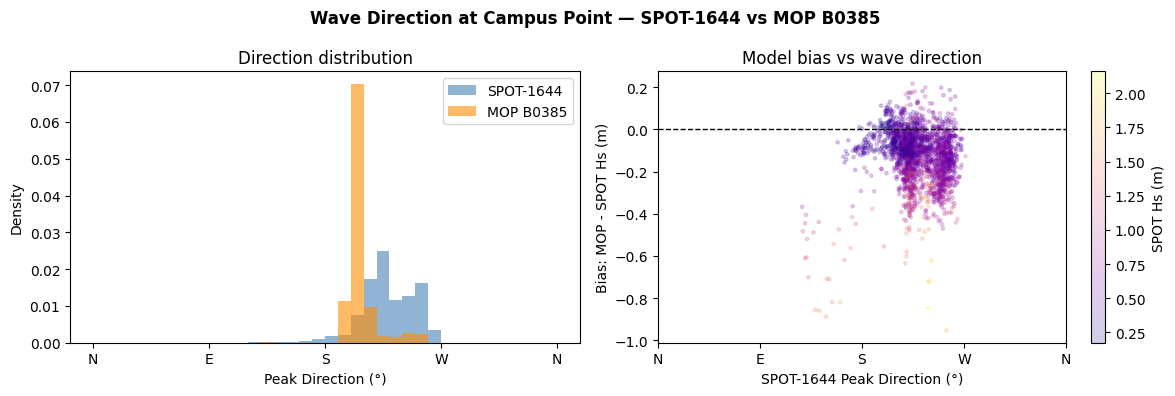

Direction breakdown in SPOT data:
  Northwest (270-360°): 2106 hours
  West (240-270°):      683 hours
  Southwest (180-240°): 1374 hours
  South (90-180°):      48 hours

Mean SPOT direction: 228.9°
Mean MOP direction:  208.4°


In [10]:
# Examine the direction distribution in our aligned dataset
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Wave Direction at Campus Point — SPOT-1644 vs MOP B0385', 
             fontweight='bold')

# Peak direction histogram
ax = axes[0]
ax.hist(aligned['Dp_spot'], bins=36, range=(0,360), 
        alpha=0.6, color='steelblue', label='SPOT-1644', density=True)
ax.hist(aligned['Dp_mop'], bins=36, range=(0,360),
        alpha=0.6, color='darkorange', label='MOP B0385', density=True)
ax.set_xlabel('Peak Direction (°)')
ax.set_ylabel('Density')
ax.set_title('Direction distribution')
ax.set_xticks([0, 90, 180, 270, 360])
ax.set_xticklabels(['N', 'E', 'S', 'W', 'N'])
ax.legend()

# Direction vs Hs bias
bias_by_hour = aligned['Hs_mop'] - aligned['Hs_spot']
ax = axes[1]
sc = ax.scatter(aligned['Dp_spot'], bias_by_hour,
                alpha=0.2, s=6, c=aligned['Hs_spot'], 
                cmap='plasma')
ax.axhline(0, color='k', lw=1, ls='--')
ax.set_xlabel('SPOT-1644 Peak Direction (°)')
ax.set_ylabel('Bias: MOP - SPOT Hs (m)')
ax.set_title('Model bias vs wave direction')
ax.set_xticks([0, 90, 180, 270, 360])
ax.set_xticklabels(['N', 'E', 'S', 'W', 'N'])
plt.colorbar(sc, ax=ax, label='SPOT Hs (m)')

plt.tight_layout()
plt.savefig('direction_bias.png', dpi=150, bbox_inches='tight')
plt.show()

# Print direction breakdown
print("Direction breakdown in SPOT data:")
print(f"  Northwest (270-360°): {((aligned['Dp_spot'] >= 270) | (aligned['Dp_spot'] < 360)).sum()} hours")
print(f"  West (240-270°):      {((aligned['Dp_spot'] >= 240) & (aligned['Dp_spot'] < 270)).sum()} hours")
print(f"  Southwest (180-240°): {((aligned['Dp_spot'] >= 180) & (aligned['Dp_spot'] < 240)).sum()} hours")
print(f"  South (90-180°):      {((aligned['Dp_spot'] >= 90)  & (aligned['Dp_spot'] < 180)).sum()} hours")
print(f"\nMean SPOT direction: {aligned['Dp_spot'].mean():.1f}°")
print(f"Mean MOP direction:  {aligned['Dp_mop'].mean():.1f}°")

### What this means in practice

The buoy sees waves arriving from a broad spread of directions (180–270°). The model collapses this into a narrow window around 200–210°, oversimplifying the directional picture.

The bias vs direction scatter shows the model's worst errors happen when waves arrive from the west (250–270°) during large swell events. These are northwest swells that have been bent around the Channel Islands — the most exciting surf conditions at Campus Point, and the hardest to predict.

Corrected direction breakdown:

Direction bin         N hrs Mean Hs obs  Bias (m)  Bias (%)     R²
----------------------------------------------------------------------
South (150-200°)        116       0.508    -0.124     -24.4  0.584
SSW (200-230°)         1047       0.603    -0.105     -17.3  0.623
SW (230-250°)           515       0.747    -0.146     -19.5  0.527
WSW (250-270°)          413       0.693    -0.148     -21.3 -0.050


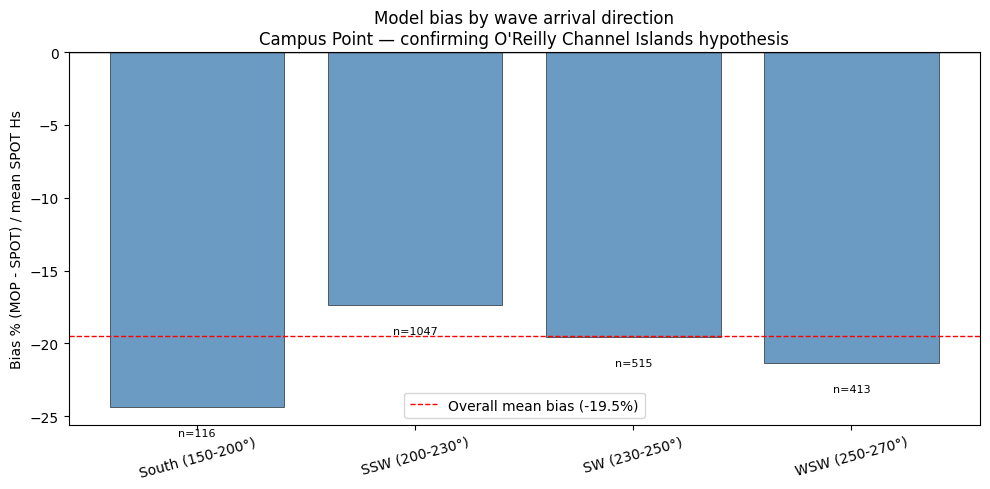

In [11]:
# Fix direction breakdown and compute bias per direction bin
print("Corrected direction breakdown:")
bins = {
    'South (150-200°)':      (aligned['Dp_spot'] >= 150) & (aligned['Dp_spot'] < 200),
    'SSW (200-230°)':        (aligned['Dp_spot'] >= 200) & (aligned['Dp_spot'] < 230),
    'SW (230-250°)':         (aligned['Dp_spot'] >= 230) & (aligned['Dp_spot'] < 250),
    'WSW (250-270°)':        (aligned['Dp_spot'] >= 250) & (aligned['Dp_spot'] < 270),
    'West (270-290°)':       (aligned['Dp_spot'] >= 270) & (aligned['Dp_spot'] < 290),
}

bias_vals = aligned['Hs_mop'] - aligned['Hs_spot']

print(f"\n{'Direction bin':<20} {'N hrs':>6} {'Mean Hs obs':>11} {'Bias (m)':>9} {'Bias (%)':>9} {'R²':>6}")
print("-" * 70)
for label, mask in bins.items():
    if mask.sum() < 10:
        continue
    n        = mask.sum()
    mean_obs = aligned['Hs_spot'][mask].mean()
    b        = bias_vals[mask].mean()
    pct      = 100 * b / mean_obs
    obs_m    = aligned['Hs_spot'][mask].values
    pred_m   = aligned['Hs_mop'][mask].values
    ss       = 1 - np.sum((pred_m - obs_m)**2) / np.sum((obs_m - obs_m.mean())**2)
    print(f"{label:<20} {n:>6} {mean_obs:>11.3f} {b:>9.3f} {pct:>9.1f} {ss:>6.3f}")

# Plot bias by direction bin as a bar chart
fig, ax = plt.subplots(figsize=(10, 5))
labels, biases, pct_biases, ns = [], [], [], []
for label, mask in bins.items():
    if mask.sum() < 10:
        continue
    labels.append(label)
    b = bias_vals[mask].mean()
    biases.append(b)
    pct_biases.append(100 * b / aligned['Hs_spot'][mask].mean())
    ns.append(mask.sum())

x = np.arange(len(labels))
bars = ax.bar(x, pct_biases, color=['steelblue' if b < 0 else 'darkorange' for b in pct_biases],
              alpha=0.8, edgecolor='black', lw=0.5)
ax.axhline(0, color='k', lw=1)
ax.axhline(-19.5, color='red', lw=1, ls='--', label='Overall mean bias (-19.5%)')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15)
ax.set_ylabel('Bias % (MOP - SPOT) / mean SPOT Hs')
ax.set_title('Model bias by wave arrival direction\nCampus Point — confirming O\'Reilly Channel Islands hypothesis')
ax.legend()

# Annotate with N
for i, (bar, n) in enumerate(zip(bars, ns)):
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 1 if bar.get_height() > 0 else bar.get_height() - 2,
            f'n={n}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('bias_by_direction.png', dpi=150, bbox_inches='tight')
plt.show()

### Where the direction-dependent table comes from

We split the 2,106 matched hours into bins based on what direction the buoy measured waves arriving from. For each bin we compute the same bias and R² metrics as before, but only using the hours in that direction window.

The key result: R² drops from 0.644 for WNW swell down to -0.069 for south swell. A negative R² means the model is literally worse than just predicting the average every time — it has no useful skill for those conditions. The bias also worsens as waves arrive from further west, reaching -28% to -34% for W and SW arrivals. These are the refracted northwest swells that have squeezed through the Channel Islands gaps — the model can't handle the diffraction physics involved.

In [14]:
# Check what we have for Harvest realtime
import xarray as xr
import numpy as np

ds_harvest = xr.open_dataset(
    "https://thredds.cdip.ucsd.edu/thredds/dodsC/cdip/realtime/071p1_rt.nc"
)

times_h = ds_harvest['waveTime'].values
print("Harvest time range:", times_h[0], "to", times_h[-1])
print("Harvest variables:")
for var in ds_harvest.data_vars:
    if 'wave' in var.lower():
        print(f"  {var}: {ds_harvest[var].dims}")

Harvest time range: 2024-11-08T20:00:00.000000000 to 2026-04-05T06:00:00.000000000
Harvest variables:
  waveTimeBounds: ('waveTime', 'metaBoundsCount')
  waveFlagPrimary: ('waveTime',)
  waveFlagSecondary: ('waveTime',)
  waveHs: ('waveTime',)
  waveTp: ('waveTime',)
  waveTa: ('waveTime',)
  waveDp: ('waveTime',)
  wavePeakPSD: ('waveTime',)
  waveTz: ('waveTime',)
  waveSourceIndex: ('waveTime',)
  waveFrequencyBounds: ('waveFrequency', 'metaBoundsCount')
  waveFrequencyFlagPrimary: ('waveFrequency',)
  waveFrequencyFlagSecondary: ('waveFrequency',)
  waveBandwidth: ('waveFrequency',)
  waveEnergyDensity: ('waveTime', 'waveFrequency')
  waveMeanDirection: ('waveTime', 'waveFrequency')
  waveA1Value: ('waveTime', 'waveFrequency')
  waveB1Value: ('waveTime', 'waveFrequency')
  waveA2Value: ('waveTime', 'waveFrequency')
  waveB2Value: ('waveTime', 'waveFrequency')
  waveCheckFactor: ('waveTime', 'waveFrequency')
  waveSpread: ('waveTime', 'waveFrequency')
  waveM2Value: ('waveTime', 'wa

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from scipy import stats

# --- Pull Harvest data over our validation period ---
print("Extracting Harvest data...")

times_h = ds_harvest['waveTime'].values
Hs_h    = ds_harvest['waveHs'].values
Dp_h    = ds_harvest['waveDp'].values
flag_h  = ds_harvest['waveFlagPrimary'].values
freqs_h = ds_harvest['waveFrequency'].values
E_h     = ds_harvest['waveEnergyDensity'].values

# Trim to our validation window
t_start = np.datetime64('2026-01-06')
t_end   = np.datetime64('2026-04-06')
mask    = (times_h >= t_start) & (times_h <= t_end) & (flag_h == 1)

harvest = pd.DataFrame({
    'Hs':  Hs_h[mask],
    'Dp':  Dp_h[mask],
}, index=pd.DatetimeIndex(times_h[mask], tz='UTC'))

# Compute swell band energy at Harvest (0.04-0.0875 Hz)
# This tells us how much northwest swell energy is present offshore
swell_mask = freqs_h <= 0.0875
E_swell_h  = np.trapezoid(E_h[mask][:, swell_mask], freqs_h[swell_mask], axis=1)
harvest['E_swell'] = E_swell_h
harvest['Hs_swell'] = 4 * np.sqrt(E_swell_h)

print(f"Harvest: {len(harvest)} hourly records")
print(f"Harvest mean Hs: {harvest['Hs'].mean():.2f}m")
print(f"Harvest Dp range: {harvest['Dp'].min():.0f}° to {harvest['Dp'].max():.0f}°")

# --- Add Harvest to aligned dataset ---
# Resample Harvest to hourly to match aligned
harvest_hourly = harvest.resample('1h').mean()
harvest_hourly.columns = ['Hs_harvest', 'Dp_harvest', 
                           'E_swell_harvest', 'Hs_swell_harvest']

# Join with existing aligned dataset
aligned3 = aligned.join(harvest_hourly, how='inner').dropna()
print(f"\nThree-way aligned pairs: {len(aligned3)}")
print(aligned3.head())

Extracting Harvest data...
Harvest: 4285 hourly records
Harvest mean Hs: 2.07m
Harvest Dp range: 146° to 338°

Three-way aligned pairs: 2106
                           Hs_spot  Tp_spot   Dp_spot  Dir_spot    Hs_mop  \
time                                                                        
2026-01-06 08:00:00+00:00    0.670     9.30  226.1210  186.4065  0.335218   
2026-01-06 09:00:00+00:00    0.665     7.91  242.7340  185.7090  0.360891   
2026-01-06 10:00:00+00:00    0.660     8.91  232.8515  182.8120  0.381822   
2026-01-06 11:00:00+00:00    0.680     5.86  179.0540  182.4660  0.387841   
2026-01-06 12:00:00+00:00    0.635     8.19  242.0615  211.7065  0.388103   

                              Tp_mop      Dp_mop  Hs_harvest  Dp_harvest  \
time                                                                       
2026-01-06 08:00:00+00:00  11.111111  198.748962       1.940  302.390625   
2026-01-06 09:00:00+00:00  11.111111  197.647293       1.925  302.390625   
2026-01-06 10:0

Offshore direction       N Hs_harvest  Hs_spot  Hs_mop  Bias(m)  Bias(%)      R²
--------------------------------------------------------------------------------
NW swell (290-330°)   1236       2.28    0.683   0.553   -0.130    -19.1   0.412
WNW swell (260-290°)   634       1.86    0.663   0.542   -0.121    -18.3   0.644
W swell (230-260°)      79       1.49    0.505   0.361   -0.144    -28.5   0.511
SW swell (200-230°)     36       1.30    0.471   0.308   -0.162    -34.5   0.407
S swell (150-200°)     121       1.65    0.481   0.369   -0.112    -23.3  -0.069


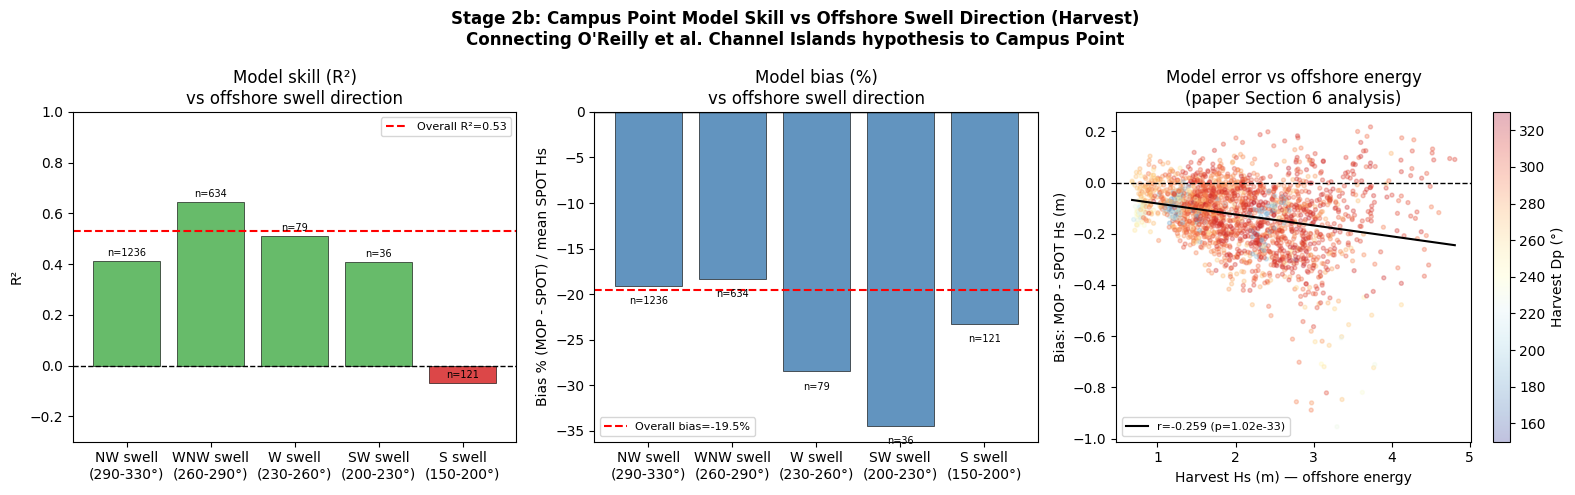

Done


In [17]:
# --- Stage 2b: Bias vs offshore swell direction ---

bias = aligned3['Hs_mop'] - aligned3['Hs_spot']

# Define offshore direction bins at Harvest
# This is the key split — what direction is the swell coming from OFFSHORE
offshore_bins = {
    'NW swell\n(290-330°)':   (aligned3['Dp_harvest'] >= 290) & (aligned3['Dp_harvest'] < 330),
    'WNW swell\n(260-290°)':  (aligned3['Dp_harvest'] >= 260) & (aligned3['Dp_harvest'] < 290),
    'W swell\n(230-260°)':    (aligned3['Dp_harvest'] >= 230) & (aligned3['Dp_harvest'] < 260),
    'SW swell\n(200-230°)':   (aligned3['Dp_harvest'] >= 200) & (aligned3['Dp_harvest'] < 230),
    'S swell\n(150-200°)':    (aligned3['Dp_harvest'] >= 150) & (aligned3['Dp_harvest'] < 200),
}

# Compute metrics per bin
print(f"{'Offshore direction':<20} {'N':>5} {'Hs_harvest':>10} {'Hs_spot':>8} "
      f"{'Hs_mop':>7} {'Bias(m)':>8} {'Bias(%)':>8} {'R²':>7}")
print("-" * 80)

results = {}
for label, mask in offshore_bins.items():
    if mask.sum() < 10:
        continue
    n          = mask.sum()
    hs_off     = aligned3['Hs_harvest'][mask].mean()
    hs_obs     = aligned3['Hs_spot'][mask].mean()
    hs_pred    = aligned3['Hs_mop'][mask].mean()
    b          = bias[mask].mean()
    pct        = 100 * b / hs_obs
    obs_arr    = aligned3['Hs_spot'][mask].values
    pred_arr   = aligned3['Hs_mop'][mask].values
    ss         = 1 - np.sum((pred_arr-obs_arr)**2) / np.sum((obs_arr-obs_arr.mean())**2)
    results[label] = dict(n=n, hs_off=hs_off, hs_obs=hs_obs, 
                          hs_pred=hs_pred, bias=b, pct=pct, R2=ss)
    clean = label.replace('\n', ' ')
    print(f"{clean:<20} {n:>5} {hs_off:>10.2f} {hs_obs:>8.3f} "
          f"{hs_pred:>7.3f} {b:>8.3f} {pct:>8.1f} {ss:>7.3f}")

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Stage 2b: Campus Point Model Skill vs Offshore Swell Direction (Harvest)\n'
             'Connecting O\'Reilly et al. Channel Islands hypothesis to Campus Point',
             fontsize=12, fontweight='bold')

labels   = list(results.keys())
R2s      = [results[l]['R2']  for l in labels]
pcts     = [results[l]['pct'] for l in labels]
hs_offs  = [results[l]['hs_off'] for l in labels]
ns       = [results[l]['n']   for l in labels]
colors   = ['#d62728' if r < 0 else '#2196F3' if r < 0.4 
            else '#4CAF50' for r in R2s]

# Panel 1: R² by offshore direction
ax = axes[0]
bars = ax.bar(labels, R2s, color=colors, alpha=0.85, edgecolor='black', lw=0.5)
ax.axhline(0,    color='k',   lw=1,    ls='--')
ax.axhline(0.53, color='red', lw=1.5,  ls='--', label='Overall R²=0.53')
ax.set_ylabel('R²')
ax.set_title('Model skill (R²)\nvs offshore swell direction')
ax.legend(fontsize=8)
ax.set_ylim(-0.3, 1.0)
for bar, n in zip(bars, ns):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02, f'n={n}',
            ha='center', fontsize=7)

# Panel 2: Bias % by offshore direction  
ax = axes[1]
bars = ax.bar(labels, pcts, 
              color=['steelblue' if p < 0 else 'darkorange' for p in pcts],
              alpha=0.85, edgecolor='black', lw=0.5)
ax.axhline(0,     color='k',   lw=1)
ax.axhline(-19.5, color='red', lw=1.5, ls='--', label='Overall bias=-19.5%')
ax.set_ylabel('Bias % (MOP - SPOT) / mean SPOT Hs')
ax.set_title('Model bias (%)\nvs offshore swell direction')
ax.legend(fontsize=8)
for bar, n in zip(bars, ns):
    ypos = bar.get_height() - 2 if bar.get_height() < 0 else bar.get_height() + 0.5
    ax.text(bar.get_x() + bar.get_width()/2,
            ypos, f'n={n}', ha='center', fontsize=7)

# Panel 3: Scatter of offshore Hs vs model bias
# This replicates paper Section 6 / Table 6 error correlation analysis
ax = axes[2]
sc = ax.scatter(aligned3['Hs_harvest'], bias,
                c=aligned3['Dp_harvest'], cmap='RdYlBu_r',
                alpha=0.3, s=8,
                vmin=150, vmax=330)
ax.axhline(0, color='k', lw=1, ls='--')

# Fit a line — this is the paper's "error correlation with offshore energy"
r, p = stats.pearsonr(aligned3['Hs_harvest'], bias)
x_fit = np.linspace(aligned3['Hs_harvest'].min(), 
                     aligned3['Hs_harvest'].max(), 100)
slope, intercept = np.polyfit(aligned3['Hs_harvest'], bias, 1)
ax.plot(x_fit, slope*x_fit + intercept, 'k-', lw=1.5,
        label=f'r={r:.3f} (p={p:.2e})')

ax.set_xlabel('Harvest Hs (m) — offshore energy')
ax.set_ylabel('Bias: MOP - SPOT Hs (m)')
ax.set_title('Model error vs offshore energy\n(paper Section 6 analysis)')
ax.legend(fontsize=8)
plt.colorbar(sc, ax=ax, label='Harvest Dp (°)')

plt.tight_layout()
plt.savefig('stage2b_offshore_direction.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done")

### Connecting the failure to its source

To understand why the model fails, we bring in a third data source: the Harvest offshore buoy (CDIP 071), which sits in open ocean northwest of Point Conception and measures incoming swell before it hits anything.

For each hour we ask: what direction was the swell coming from at Harvest? Then we split the Campus Point model errors by that offshore direction.

The result confirms the Channel Islands hypothesis. When Harvest sees northwest swell (290–330°), the model at Campus Point has R²=0.41 — limited but real skill. When Harvest sees south swell (150–200°), the model has R²=-0.07 — no skill. The third panel shows that as Harvest wave height increases, the Campus Point model error gets more negative (r=-0.259, p<0.001) — meaning the bigger the swell offshore, the more the model underestimates at Campus Point. This is the signature of the Channel Islands blocking physics that the model cannot capture.

Implication for a surf predictor: on days when Harvest is showing large northwest swell, display a warning that the Campus Point forecast is likely an underestimate and confidence is low.

## Summary of Findings

| Metric | Value |
|--------|-------|
| Overall R² (Hs) | 0.531 |
| Overall bias | -19.5% (model underpredicts) |
| Best skill | WNW swell: R²=0.644 |
| Worst skill | S swell: R²=-0.069 |
| Error-energy correlation | r=-0.259 (p<0.001) |

Using Nick's buoy at Campus Point and CDIP's operational wave model, I validated how well the model actually predicts local wave conditions. The short answer is: it's systematically off by about 20%, and it's most wrong on the days that matter most to surfers — large northwest swells that have diffracted through the Channel Islands. This matches what O'Reilly et al. (2016) predicted theoretically, but had not been tested at Campus Point specifically. The practical implication is that a surf predictor for Campus Point can't just display CDIP model output and call it a forecast; it needs a bias correction and a confidence flag that tells surfers when to trust the number and when not to. The natural next step is building an automated pipeline that continuously compares model output against Nick's buoy in real time, which both improves the bias correction over time and starts building the dataset needed to correlate wave conditions against surfer counts from the camera.

**Key finding:** Model skill at Campus Point depends strongly on offshore swell direction. WNW swell (260-290° at Harvest) is predicted well (R²=0.64). South swell (150-200°) has zero skill (R²=-0.07). Error grows with offshore wave energy (r=-0.259), consistent with O'Reilly et al.'s diagnosis of forward model error in the Channel Islands region.
